## Block 1 — Environment Initialization & Data Ingestion
**Rationale:** The raw Amazon Kindle Reviews dataset exceeds 500MB and must be ingested into a distributed Spark DataFrame for scalable processing.

**Technical Implementation:** We initialize a `SparkSession` with local Hadoop configurations and load the raw CSV, utilizing `inferSchema=True` to automatically map column data types.

In [ ]:
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from google.colab import drive

drive.mount('/content/drive')

os.environ['HADOOP_HOME'] = "C:\\hadoop"
os.environ['PATH'] += os.pathsep + "C:\\hadoop\\bin"

spark = SparkSession.builder \
    .appName('BT4221_Data_Cleaning') \
    .getOrCreate()

RAW_DATA_PATH = '/content/drive/MyDrive/BT4221/kindle_reviews.csv'
df_raw = spark.read.csv(RAW_DATA_PATH, header=True,
    inferSchema=True,
    multiLine=True,
    escape='"',
    quote='"')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Block 2 — Text Quality Filtering & Schema Pruning
**Rationale:** Unstructured review text contains noise (nulls, empty strings, and micro-reviews) which degrades NLP feature extraction. Extra columns consume unnecessary cluster memory.

**Technical Implementation:** We apply PySpark string functions (`trim`, `length`) to filter valid text, drop redundant categorical metadata, and execute a blanket `.dropna()` to ensure strict data completeness.

In [ ]:
from pyspark.sql import functions as F

# 1. Capture the initial state
original_count = df_raw.count()

# 2. Filter out nulls, empty strings, and super short entries
df_cleaned = df_raw.filter(
    F.col("reviewText").isNotNull() &
    (F.trim(F.col("reviewText")) != "") &
    (F.length(F.col("reviewText")) >= 3)
)

# 3. Capture the final state
cleaned_count = df_cleaned.count()
removed_count = original_count - cleaned_count

# 4. Display results with formatted numbers for readability
print(f"Original number of rows:       {original_count:,}")
print(f"Number of rows after cleaning: {cleaned_count:,}")
print(f"Number of rows removed:        {removed_count:,}")

# 5. Verify the output
df_cleaned.show(5)

Original number of rows:       982,619
Number of rows after cleaning: 982,581
Number of rows removed:        38
+---+----------+-------+-------+--------------------+-----------+--------------+--------------------+------------------+--------------+
|_c0|      asin|helpful|overall|          reviewText| reviewTime|    reviewerID|        reviewerName|           summary|unixReviewTime|
+---+----------+-------+-------+--------------------+-----------+--------------+--------------------+------------------+--------------+
|  0|B000F83SZQ| [0, 0]|      5|I enjoy vintage b...| 05 5, 2014|A1F6404F1VG29J|          Avidreader|Nice vintage story|    1399248000|
|  1|B000F83SZQ| [2, 2]|      4|This book is a re...| 01 6, 2014| AN0N05A9LIJEQ|            critters|      Different...|    1388966400|
|  2|B000F83SZQ| [2, 2]|      4|This was a fairly...| 04 4, 2014| A795DMNCJILA6|                 dot|             Oldie|    1396569600|
|  3|B000F83SZQ| [1, 1]|      5|I'd never read an...|02 19, 2014|A1FV0SX

## Block 3 — Initial Schema Refinement & Null Handling
**Rationale:** Real-world datasets often contain sparse records. We perform a global dropna to ensure that every review passed to the ML models has a complete set of features (User, Item, Rating, and Text).

**Technical Implementation:** We prune irrelevant metadata columns first to save memory, then execute a blanket `.dropna()` and a consolidated null-count audit using a single Spark action.

In [ ]:
# 1. Column Pruning: Focus memory on features required for recommendation
COLS_TO_DROP = ["summary", "unixReviewTime", "_c0", "reviewerName"]
df_pruned = df_raw.drop(*COLS_TO_DROP)

# 2. Strict Null Removal: Behavioral match to old code's .dropna()
df_cleaned = df_pruned.dropna()

# 3. Consolidated Null Audit: Efficient single-pass count
null_exprs = [F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_cleaned.columns]
null_counts = df_cleaned.select(null_exprs).collect()[0]

print("Null counts per column (post-cleaning):")
for col in df_cleaned.columns:
    print(f" - {col}: {null_counts[col]}")

Null counts per column (post-cleaning):
 - asin: 0
 - helpful: 0
 - overall: 0
 - reviewText: 0
 - reviewTime: 0
 - reviewerID: 0


## Block 4 — Temporal Consistency & ASIN Mapping
**Rationale:** The `reviewTime` must be cast from a String to a Date type to support chronological splitting. We also rename the `asin` column to `bookID` to match standard industry terminology for item identifiers.

**Technical Implementation:** We use `to_date` with a specific format string. Rows where the date parsing fails (resulting in a null) are explicitly filtered out.

In [ ]:
# Standardise temporal data and map item identifiers
# to_date returns null on failure, which we filter to ensure data integrity.
df_temporal = df_cleaned.withColumn(
    "reviewTime",
    F.to_date(F.col("reviewTime"), "MM d, yyyy")
).filter(F.col("reviewTime").isNotNull()) \
 .withColumnRenamed('asin', 'bookID')

# Validate schema and show data distribution
df_temporal.select("reviewerID", "bookID", "reviewTime").show(5)

+--------------+----------+----------+
|    reviewerID|    bookID|reviewTime|
+--------------+----------+----------+
|A1F6404F1VG29J|B000F83SZQ|2014-05-05|
| AN0N05A9LIJEQ|B000F83SZQ|2014-01-06|
| A795DMNCJILA6|B000F83SZQ|2014-04-04|
|A1FV0SX13TWVXQ|B000F83SZQ|2014-02-19|
|A3SPTOKDG7WBLN|B000F83SZQ|2014-03-19|
+--------------+----------+----------+
only showing top 5 rows


## Block 5 — K-Core Stage 1: Item-Level Thresholding

**Rationale:** Books with very few reviews provide insufficient signal for the ML models to learn meaningful patterns (the "Cold Start" problem). We retain only "high-density" items.

**Technical Implementation:** We utilize a `groupBy` and `filter` pattern to create a "Keep List" of bookIDs with more than 50 reviews, then perform a distributed inner join to prune the main DataFrame.

In [ ]:
# Isolate books with significant interaction history (> 50 reviews)
keep_books = df_temporal.groupBy('bookID') \
    .count() \
    .filter(F.col('count') > 50) \
    .select('bookID')

df_book_filtered = df_temporal.join(keep_books, on='bookID', how='inner')

print(f"Rows remaining after Item-Level filtering: {df_book_filtered.count():,}")

Rows remaining after Item-Level filtering: 249,566


## Block 6 — K-Core Stage 2: User-Level Thresholding & Materialization

**Rationale:** For recommendation systems to be effective, we require a minimum number of data points per user to build a reliable preference profile.

**Technical Implementation:** Following the same Join-based behavior as Stage 1, we filter for users with $\ge 10$ reviews. We then `.cache()` the final result to lock the execution plan (DAG) before the ML training begins.

In [ ]:
# Retain users with at least 10 reviews in their history
keep_users = df_book_filtered.groupBy('reviewerID') \
    .count() \
    .filter(F.col('count') >= 10) \
    .select('reviewerID')

df_final = df_book_filtered.join(keep_users, on='reviewerID', how='inner')

# Cache the dataset to prevent redundant re-computation during ML splitting
df_final.cache()

final_size = df_final.count()
print(f"Final K-Core dataset size: {final_size:,} rows")

Final K-Core dataset size: 102,784 rows


## Block 6b — Exploratory Data Analysis

**Rationale:** Before modelling, we conduct a systematic analysis of the cleaned dataset to understand its distributional properties and validate our design decisions. The following visualisations directly inform the pipeline architecture: class imbalance handling, K-core thresholds, temporal splitting, and the need for LLM-based feature extraction.

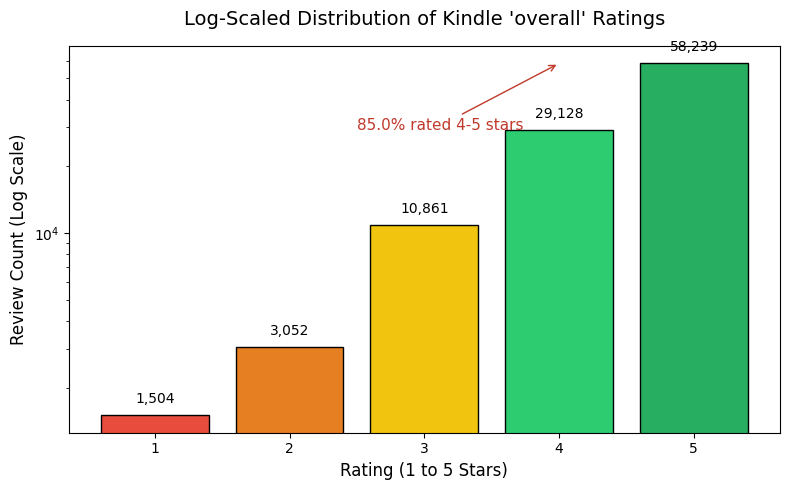


Rating breakdown:
  1 stars: 1,504 (1.5%)
  2 stars: 3,052 (3.0%)
  3 stars: 10,861 (10.6%)
  4 stars: 29,128 (28.3%)
  5 stars: 58,239 (56.7%)

Positive (4-5 stars): 87,367 (85.0%)
Negative (1-3 stars): 15,417 (15.0%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rating distribution on final cleaned dataset
rating_counts = df_final.groupBy("overall").count().orderBy("overall").toPandas()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rating_counts["overall"].astype(str),
    rating_counts["count"],
    color=["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"],
    edgecolor="black"
)
plt.yscale("log")
plt.title("Log-Scaled Distribution of Kindle 'overall' Ratings", fontsize=14, pad=15)
plt.xlabel("Rating (1 to 5 Stars)", fontsize=12)
plt.ylabel("Review Count (Log Scale)", fontsize=12)

# Add count labels on top of bars
for bar, count in zip(bars, rating_counts["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
             f"{count:,}", ha="center", va="bottom", fontsize=10)

# Add percentage annotation
total = rating_counts["count"].sum()
positive = rating_counts[rating_counts["overall"] >= 4]["count"].sum()
pct = positive / total * 100
plt.annotate(f"{pct:.1f}% rated 4-5 stars",
             xy=(3, rating_counts[rating_counts["overall"]==5]["count"].values[0]),
             xytext=(1.5, rating_counts["count"].max() * 0.5),
             fontsize=11, color="#c0392b",
             arrowprops=dict(arrowstyle="->", color="#c0392b"))

plt.tight_layout()
plt.savefig("rating_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

# Print the numbers for the report
print("\nRating breakdown:")
for _, row in rating_counts.iterrows():
    print(f"  {int(row['overall'])} stars: {row['count']:,} ({row['count']/total*100:.1f}%)")
print(f"\nPositive (4-5 stars): {positive:,} ({pct:.1f}%)")
print(f"Negative (1-3 stars): {total-positive:,} ({100-pct:.1f}%)")

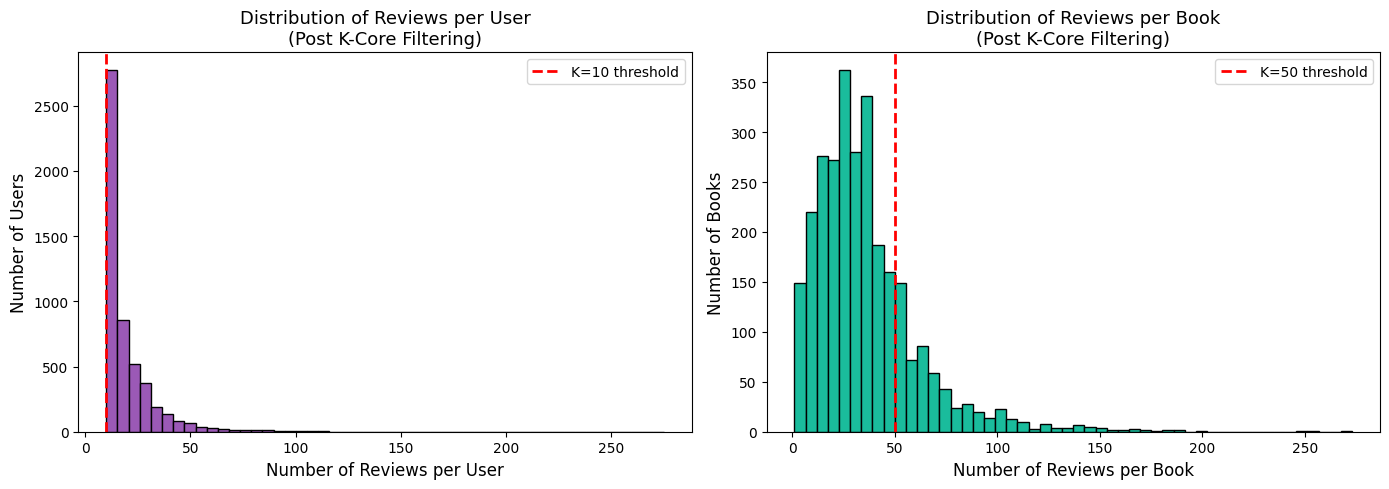

Unique users  : 5,174
Unique books  : 2,836
Total reviews : 102,784


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Reviews per user ──────────────────────────────────────────────────
user_counts = df_final.groupBy("reviewerID").count().select("count").toPandas()

# ── Reviews per book ──────────────────────────────────────────────────
book_counts = df_final.groupBy("bookID").count().select("count").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reviews per user
axes[0].hist(user_counts["count"], bins=50, color="#9b59b6", edgecolor="black")
axes[0].axvline(x=10, color="red", linestyle="--", linewidth=2, label="K=10 threshold")
axes[0].set_xlabel("Number of Reviews per User", fontsize=12)
axes[0].set_ylabel("Number of Users", fontsize=12)
axes[0].set_title("Distribution of Reviews per User\n(Post K-Core Filtering)", fontsize=13)
axes[0].legend()

# Reviews per book
axes[1].hist(book_counts["count"], bins=50, color="#1abc9c", edgecolor="black")
axes[1].axvline(x=50, color="red", linestyle="--", linewidth=2, label="K=50 threshold")
axes[1].set_xlabel("Number of Reviews per Book", fontsize=12)
axes[1].set_ylabel("Number of Books", fontsize=12)
axes[1].set_title("Distribution of Reviews per Book\n(Post K-Core Filtering)", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig("review_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Unique users  : {df_final.select('reviewerID').distinct().count():,}")
print(f"Unique books  : {df_final.select('bookID').distinct().count():,}")
print(f"Total reviews : {df_final.count():,}")

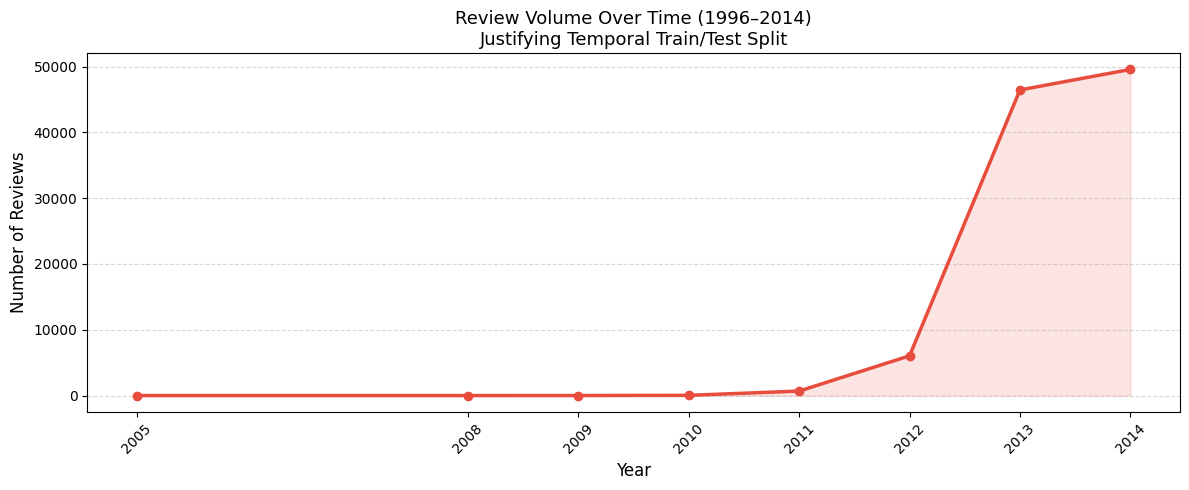

In [ ]:
# ── Review volume over time ───────────────────────────────────────────
time_pd = df_final.withColumn("year", F.year("reviewTime")) \
    .groupBy("year").count().orderBy("year").toPandas()

plt.figure(figsize=(12, 5))
plt.plot(time_pd["year"], time_pd["count"], marker="o", color="#e74c3c", linewidth=2.5, markersize=6)
plt.fill_between(time_pd["year"], time_pd["count"], alpha=0.15, color="#e74c3c")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.title("Review Volume Over Time (1996–2014)\nJustifying Temporal Train/Test Split", fontsize=13)
plt.xticks(time_pd["year"], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("review_over_time.png", bbox_inches="tight", dpi=150)
plt.show()

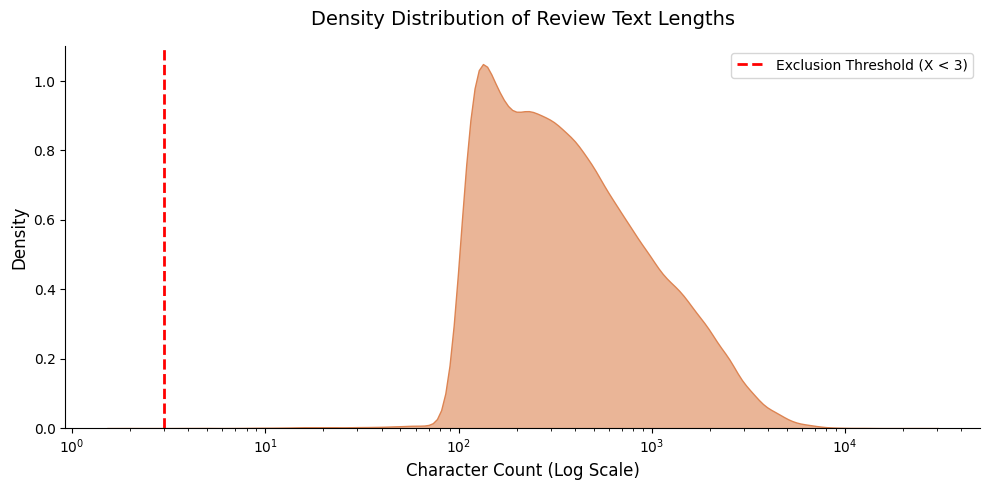

In [ ]:
# ── Review text length distribution (Pre-cleaning) ──────────────────────────────────
# Calculate lengths in Spark, then sample 10% to prevent Pandas from crashing on Colab
df_lengths = df_raw.withColumn("text_len", F.length(F.col("reviewText")))
# Filter out nulls just for the plot calculation
df_lengths = df_lengths.filter(F.col("text_len").isNotNull())

# Taking a 10% sample is mathematically sufficient for a density curve
sample_lengths = df_lengths.select("text_len").sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(10, 5))
# Use log_scale=True because text lengths usually have a massive right tail
sns.kdeplot(data=sample_lengths, x="text_len", log_scale=True, fill=True, color="#DD8452", alpha=0.6)

# The red cut-off line
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label="Exclusion Threshold (X < 3)")

plt.title("Density Distribution of Review Text Lengths", fontsize=14, pad=15)
plt.xlabel("Character Count (Log Scale)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

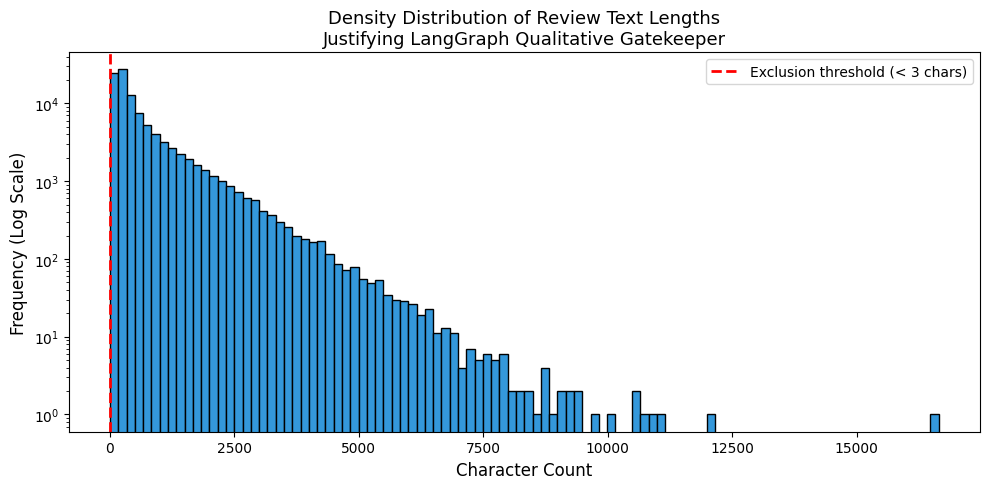

Mean review length  : 671 chars
Median review length: 329 chars
Min review length   : 4 chars


In [ ]:
# ── Review text length distribution ──────────────────────────────────
text_len_pd = df_final \
    .withColumn("text_len", F.length(F.col("reviewText"))) \
    .select("text_len").toPandas()

plt.figure(figsize=(10, 5))
plt.hist(text_len_pd["text_len"], bins=100, color="#3498db", edgecolor="black", log=True)
plt.axvline(x=3, color="red", linestyle="--", linewidth=2, label="Exclusion threshold (< 3 chars)")
plt.xlabel("Character Count", fontsize=12)
plt.ylabel("Frequency (Log Scale)", fontsize=12)
plt.title("Density Distribution of Review Text Lengths\nJustifying LangGraph Qualitative Gatekeeper", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("text_length_dist.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Mean review length  : {text_len_pd['text_len'].mean():.0f} chars")
print(f"Median review length: {text_len_pd['text_len'].median():.0f} chars")
print(f"Min review length   : {text_len_pd['text_len'].min()} chars")

  INTERACTION MATRIX DIAGNOSTICS
  Unique users        : 5,174
  Unique books        : 2,836
  Total interactions  : 102,784
  Max possible        : 14,673,464
  Matrix sparsity     : 99.30%


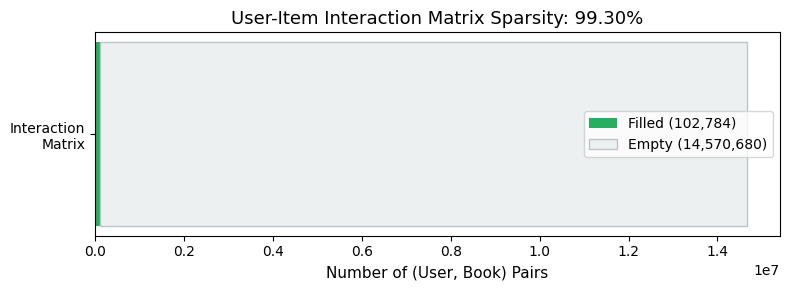

In [ ]:
# ── Interaction matrix sparsity ───────────────────────────────────────
n_users = df_final.select("reviewerID").distinct().count()
n_books = df_final.select("bookID").distinct().count()
n_interactions = df_final.count()
max_possible = n_users * n_books
sparsity = (1 - n_interactions / max_possible) * 100

print("=" * 50)
print("  INTERACTION MATRIX DIAGNOSTICS")
print("=" * 50)
print(f"  Unique users        : {n_users:,}")
print(f"  Unique books        : {n_books:,}")
print(f"  Total interactions  : {n_interactions:,}")
print(f"  Max possible        : {max_possible:,}")
print(f"  Matrix sparsity     : {sparsity:.2f}%")
print("=" * 50)

# Visualise as a simple bar showing filled vs empty
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(["Interaction\nMatrix"], [n_interactions], color="#27ae60", label=f"Filled ({n_interactions:,})")
ax.barh(["Interaction\nMatrix"], [max_possible - n_interactions], left=n_interactions,
        color="#ecf0f1", edgecolor="#bdc3c7", label=f"Empty ({max_possible - n_interactions:,})")
ax.set_xlabel("Number of (User, Book) Pairs", fontsize=11)
ax.set_title(f"User-Item Interaction Matrix Sparsity: {sparsity:.2f}%", fontsize=13)
ax.legend(loc="center right")
plt.tight_layout()
plt.savefig("sparsity.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name="Dataset Density",
    orientation="v",
    measure=["absolute", "relative", "relative", "total"],
    x=["Raw Kindle Data", "Schema & Null Pruning", "K-Core Bipartite Filter (User>=10, Item>=50)", "Final Dense Matrix"],
    textposition="outside",
    # The math: 982,619 (Raw) - 38 (Length filter/Nulls) - 879,797 (K-Core) = 102,784 (Final)
    text=["982,619", "-38", "-879,797", "102,784"],
    y=[982619, -38, -879797, 102784],
    connector={"line":{"color":"rgb(63, 63, 63)", "width": 2}},
    decreasing={"marker":{"color":"#E66C37"}},
    increasing={"marker":{"color":"#118DFF"}},
    totals={"marker":{"color":"#2CA02C"}}
))

fig.update_layout(
    title=dict(
        text="PySpark Data Pruning Pipeline: Achieving Matrix Density",
        font=dict(size=18)
    ),
    yaxis_title="Row Count",
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='lightgray'),
    showlegend=False,
    width=900,
    height=550
)

fig.show()

## Block 7 — Data Partitioning & Export
**Rationale:** The finalized, dense dataset must be batched for LLM feature extraction in Notebook 2. Sending all rows at once would trigger OpenAI API rate limits and out-of-memory errors.

**Technical Implementation:** We use `randomSplit` to create 6 uniform partitions. We deliberately use `coalesce(1)` to force Spark to write a single CSV file per chunk, optimizing for iterative downstream ingestion rather than distributed writing.

In [ ]:
# Partition data into 6 equal chunks for rate-limit-safe API processing
weights = [1.0] * 6
chunks = df_final.randomSplit(weights, seed=123)

for i, chunk in enumerate(chunks):
    chunk.coalesce(1).write.csv(
        f"split_review_{i+1}",
        header=True,
        mode="overwrite"
    )

print("Batch partitioning and export complete.")

Batch partitioning and export complete.
